In [1]:
from typing import Sequence
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr
import ml_tools as mlt
import spatial_hazard as sh
import sha_calc as sha

In [2]:
result_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0405_0928_ind_model_loth_baker_corrs_sc_loss")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [22]:
val_sample_df = pd.read_parquet(result_dir / "val_sample_results.parquet")
val_sc_df = pd.read_parquet(result_dir / "val_scenario_results.parquet")

# Add int rel id column
val_sample_df["rel_int_id"] = np.char.lstrip(val_sample_df.rel_id.values.astype(str), "REL_").astype(int)
val_sc_df["rel_int_id"] = np.char.lstrip(val_sc_df.rel_id.values.astype(str), "REL_").astype(int)

In [23]:
db = sr.db.DB(db_ffp)

all_sites = db.get_avail_sites()
station_df = db.get_site_df()

dist_matrix = sh.im_dist.calculate_distance_matrix(all_sites, station_df)

val_sample_df["s2s_dist"] = dist_matrix.values[dist_matrix.index.get_indexer_for(val_sample_df["site_int"].values), dist_matrix.columns.get_indexer_for(val_sample_df["site_obs"].values)]

for cur_im in sr.constants.PSA_KEYS:
	val_sample_df[f"{cur_im}_site_corr"] = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, val_sample_df["s2s_dist"].values)

In [24]:
# Config
ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]
# ims = ["pSA_0.02","pSA_0.75", "pSA_1.5", "pSA_7.5"]
# ims = ["pSA_1.0"]

# event = "3528839"
# site_int = "CBGS"

event = "3528839"
site_int = "ASHS"

prob_cols = mlt.array_utils.numpy_str_join("_", sr.constants.PSA_KEYS, "prob")
misfit_cols = mlt.array_utils.numpy_str_join("_", sr.constants.PSA_KEYS, "misfit")
residual_cols = mlt.array_utils.numpy_str_join("_", sr.constants.PSA_KEYS, "residual")

In [25]:
# Adjust for current event and site of interest
val_sample_df = val_sample_df.loc[(val_sample_df.event_id == event) & (val_sample_df.site_int == site_int)].sort_values("rel_int_id")
val_sc_df = val_sc_df.loc[(val_sc_df.event_id == event) & (val_sc_df.site_int == site_int)].sort_values("rel_int_id")

sim_df = db.get_sim_data(event, [site_int]).set_index("rel_id")
obs_df = db.get_obs_df(log=True).loc[f"{event}_{site_int}"]

In [ ]:
# Scenario probability distribution
bins = 20
bin_range = (0, 0.3)

for cur_im in ims:
	fig = plt.figure(figsize=(12, 6))
	
	plt.hist(val_sc_df[f"{cur_im}_prob"], bins=bins, range=bin_range)
	plt.xlabel(f"Probability")
	plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	plt.title(f"Scenario Probability Distribution for {cur_im}")
	plt.xlim(bin_range)
	
	plt.tight_layout()


,pSA_0.01_prob,pSA_0.02_prob,pSA_0.03_prob,pSA_0.04_prob,pSA_0.05_prob,pSA_0.075_prob,pSA_0.1_prob,pSA_0.12_prob,pSA_0.15_prob,pSA_0.17_prob,...,pSA_1.5_residual,pSA_2.0_residual,pSA_2.5_residual,pSA_3.0_residual,pSA_4.0_residual,pSA_5.0_residual,pSA_6.0_residual,pSA_7.5_residual,pSA_10.0_residual,rel_int_id


In [26]:
val_sc_df[prob_cols].max().max()

0.6217042378525536

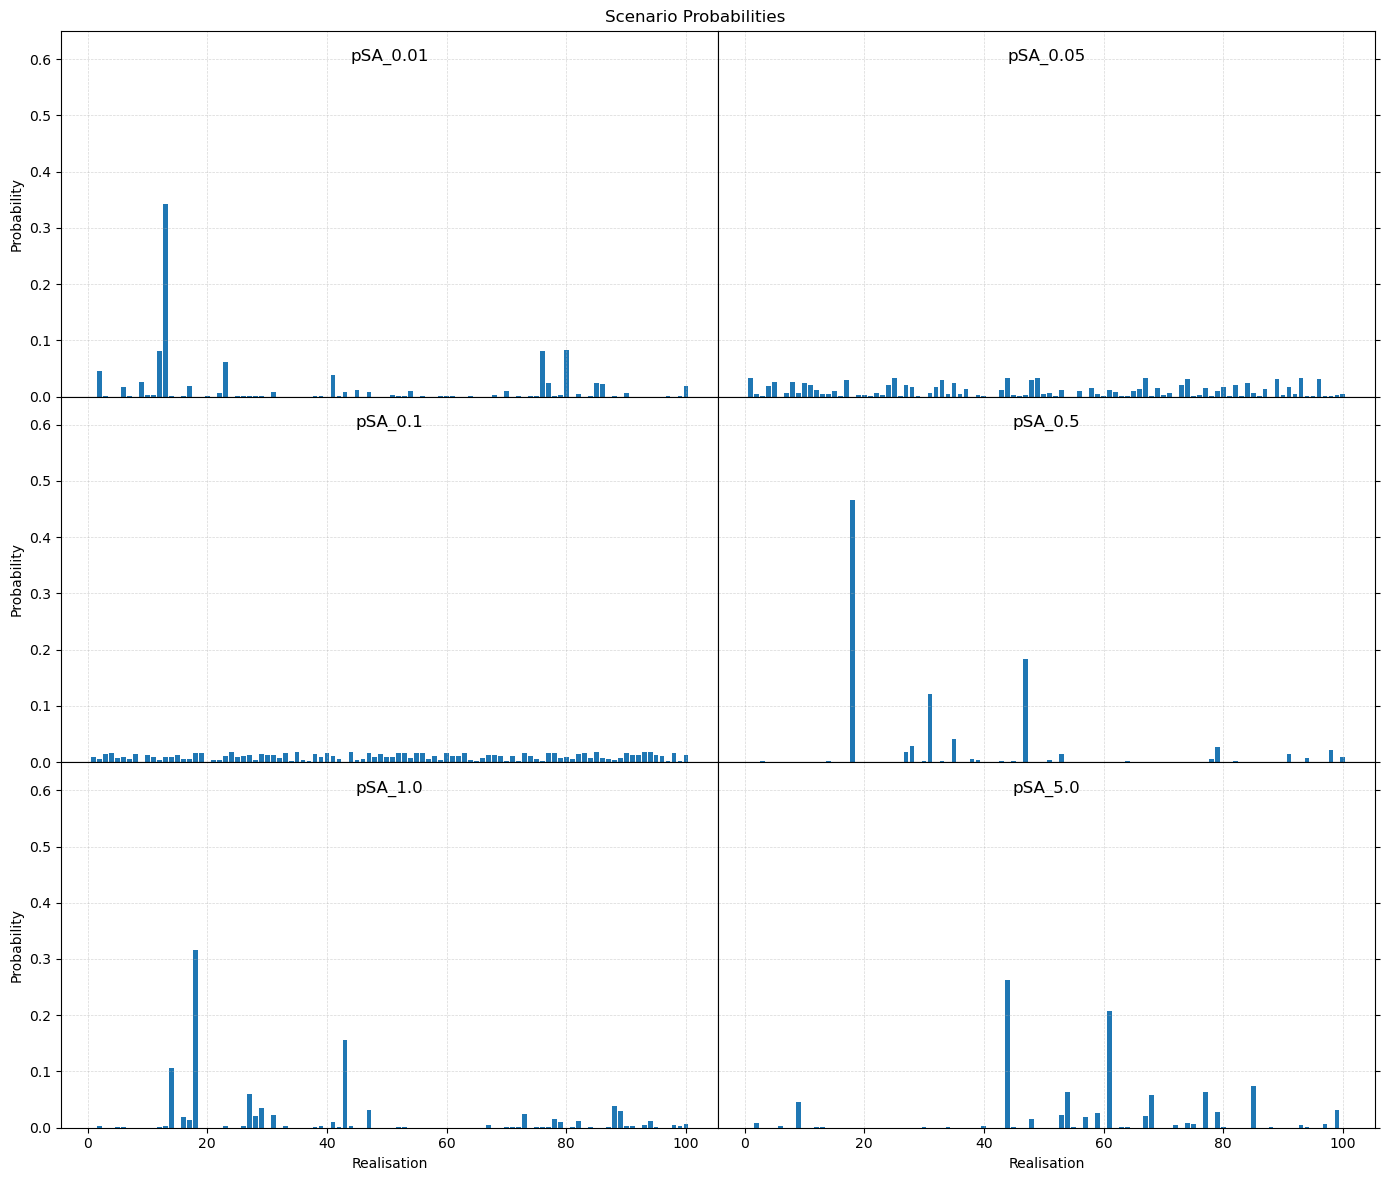

In [27]:
# Scenario probability bar plot
ylims = (0, 0.65)

fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for ix, (cur_ax, cur_im) in enumerate(zip(axs.ravel(), ims)):
	cur_ax.bar(val_sc_df.rel_int_id, val_sc_df[f"{cur_im}_prob"])
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	
	if ix >= 4:
		cur_ax.set_xlabel(f"Realisation")
	if ix % 2 == 0:
		cur_ax.set_ylabel(f"Probability")
		
	if ix % 2 == 1:
		cur_ax.set_yticklabels([])
		cur_ax.yaxis.tick_right()
		
	# cur_ax.set_title(f"{cur_im}")
	cur_ax.set_ylim(ylims)
	cur_ax.text(0.5, 0.95, f"{cur_im}", horizontalalignment="center", verticalalignment="top", transform=cur_ax.transAxes, fontsize=12)
	
	
fig.suptitle("Scenario Probabilities")
fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

In [30]:
w_std = []
w_mean = []

assert np.all(val_sc_df.rel_id.values == sim_df.index.values)

for cur_im in sr.constants.PSA_KEYS:
	
	cur_probs = val_sc_df[f"{cur_im}_prob"].values
	assert np.isclose(cur_probs.sum(), 1.0) 
	
	cur_im_values = sim_df[cur_im].values
	
	cur_w_mean = np.sum(cur_probs * cur_im_values)
	cur_w_std = np.sqrt(np.sum(cur_probs * (cur_im_values - cur_w_mean) ** 2))
	
	w_mean.append(cur_w_mean)
	w_std.append(cur_w_std)

w_std = np.asarray(w_std)
w_mean = np.asarray(w_mean)

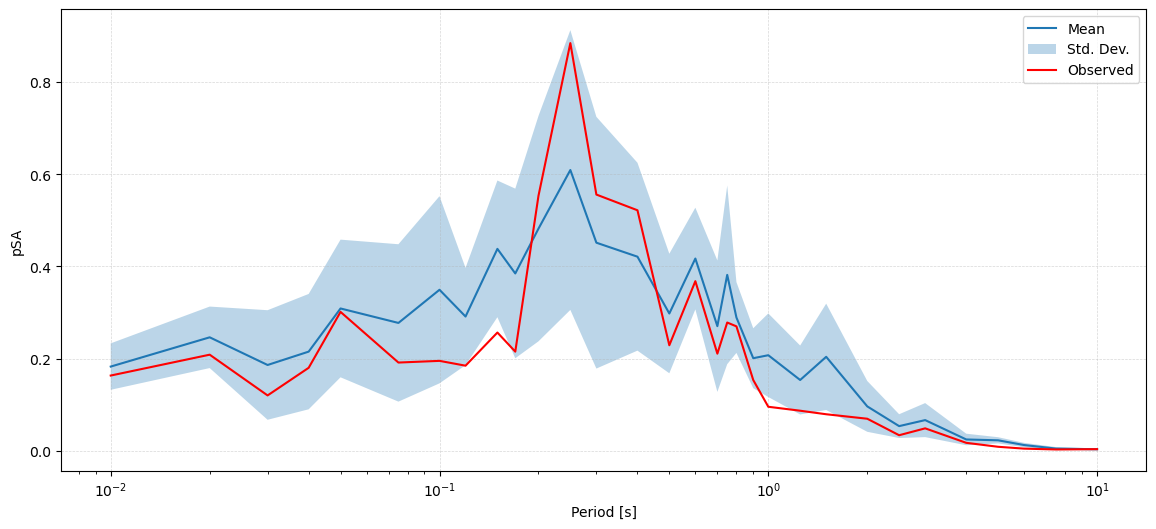

In [31]:
fig = plt.figure(figsize=(14, 6))

plt.semilogx(sr.constants.PERIODS, w_mean, label="Mean")
plt.fill_between(sr.constants.PERIODS, w_mean - w_std, w_mean + w_std, alpha=0.3, label="Std. Dev.")

plt.plot(sr.constants.PERIODS, np.exp(obs_df[sr.constants.PSA_KEYS].values.astype(float)), label="Observed", color="r", linestyle="-")

plt.xlabel("Period [s]")
plt.ylabel("pSA")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.legend()